# 0.0 Initial setting
## 0.1 Python's Libraries Imports

In [110]:
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

## 0.2 SQL connection and Data Import

In [111]:
host = "212.227.148.202"
user = "Equipo32"
password = "E1q2u3i4p5o32"
db = "Equip_32"

connection = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=db
)

if connection.is_connected():
    print("Conexión exitosa")

query = """
SELECT *
FROM BANK_marketing;
"""

df = pd.read_sql(query, connection)

df.head()

Conexión exitosa


/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_76998/2909874624.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 0.3 Hue Style

In [112]:
# General graph style

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# 1. Data Undestanding

## 1.1 Basic exploration

In [113]:
df.shape

(10642, 18)

In [114]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'deposit'],
      dtype='str')

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  str    
 3   marital    10637 non-null  str    
 4   education  10635 non-null  str    
 5   default    10642 non-null  str    
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  str    
 8   loan       10642 non-null  str    
 9   contact    10642 non-null  str    
 10  day        10642 non-null  int64  
 11  month      10642 non-null  str    
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  str    
 17  deposit    10642 non-null  str    
dtypes: float64(1), int64(7), str(10)
memory usage: 1.5 MB


In [116]:
connection.close()

In [117]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing[missing["missing_count"] > 0]

,missing_count,missing_percent
age,9,0.08
marital,5,0.05
education,7,0.07


In [118]:
# ver que filas tienen nulos
df[df.isna().any(axis=1)]

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1088,1089,53.0,management,NaN,secondary,no,1004,no,yes,telephone,22,dec,119,1,-1,0,unknown,yes
1181,1182,NaN,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
1300,1301,37.0,technician,married,NaN,no,549,no,no,cellular,2,mar,239,1,-1,0,unknown,yes
1410,1411,NaN,blue-collar,married,primary,no,4979,no,no,telephone,6,apr,180,1,-1,0,unknown,yes
2943,2944,24.0,student,single,NaN,no,382,no,no,cellular,13,nov,256,2,92,3,failure,yes
3719,3720,68.0,retired,NaN,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
4019,4020,NaN,services,single,secondary,no,1934,no,no,cellular,29,sep,271,1,-1,0,unknown,yes
4737,4738,37.0,management,single,NaN,no,102,yes,no,cellular,6,may,445,1,258,2,failure,yes
4854,4855,34.0,management,NaN,tertiary,no,5,no,no,cellular,18,aug,370,2,-1,0,unknown,yes
5680,5681,NaN,technician,single,tertiary,no,720,no,no,cellular,12,aug,234,4,-1,0,unknown,no


In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df["id"].duplicated().sum()

np.int64(0)

## 1.2 Data description

In [121]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,10642.000000,10633.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000
mean,5321.500000,41.252610,1536.614828,15.645461,378.693197,2.496147,52.073670,0.851344
std,3072.225117,12.003015,3223.419300,8.432874,351.180910,2.694660,109.208889,2.321755
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2661.250000,32.000000,127.000000,8.000000,141.000000,1.000000,-1.000000,0.000000
50%,5321.500000,39.000000,558.000000,15.000000,260.000000,2.000000,-1.000000,0.000000
75%,7981.750000,49.000000,1728.750000,22.000000,510.000000,3.000000,57.750000,1.000000
max,10642.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [122]:
df["deposit"].value_counts()

deposit
no     5353
yes    5289
Name: count, dtype: int64

In [123]:
df.describe(include="all")

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,10642.000000,10633.000000,10642,10637,10635,10642,10642.000000,10642,10642,10642,10642.000000,10642,10642.000000,10642.000000,10642.000000,10642.000000,10642,10642
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2447,6030,5216,10487,NaN,5660,9270,7707,NaN,2646,NaN,NaN,NaN,NaN,7885,5353
mean,5321.500000,41.252610,NaN,NaN,NaN,NaN,1536.614828,NaN,NaN,NaN,15.645461,NaN,378.693197,2.496147,52.073670,0.851344,NaN,NaN
std,3072.225117,12.003015,NaN,NaN,NaN,NaN,3223.419300,NaN,NaN,NaN,8.432874,NaN,351.180910,2.694660,109.208889,2.321755,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,2661.250000,32.000000,NaN,NaN,NaN,NaN,127.000000,NaN,NaN,NaN,8.000000,NaN,141.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,5321.500000,39.000000,NaN,NaN,NaN,NaN,558.000000,NaN,NaN,NaN,15.000000,NaN,260.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,7981.750000,49.000000,NaN,NaN,NaN,NaN,1728.750000,NaN,NaN,NaN,22.000000,NaN,510.000000,3.000000,57.750000,1.000000,NaN,NaN


In [124]:
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print()
    print(df[col].value_counts())


job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

marital
married     6030
single      3374
divorced    1233
Name: count, dtype: int64

education
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: count, dtype: int64

default
no     10487
yes      155
Name: count, dtype: int64

housing
no     5660
yes    4982
Name: count, dtype: int64

loan
no     9270
yes    1372
Name: count, dtype: int64

contact
cellular     7707
unknown      2196
telephone     739
Name: count, dtype: int64

month
may    2646
aug    1450
jul    1429
jun    1174
nov     898
apr     888
feb     746
oct     387
jan     327
sep     314
mar     274
dec     109
Name: count, dtype: int64

poutcome
unknown    7885
failure    1180
success    1065
other     

/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_76998/3651939843.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include="object").columns


## 1.3 Data distribution

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>, <Axes: >]], dtype=object)

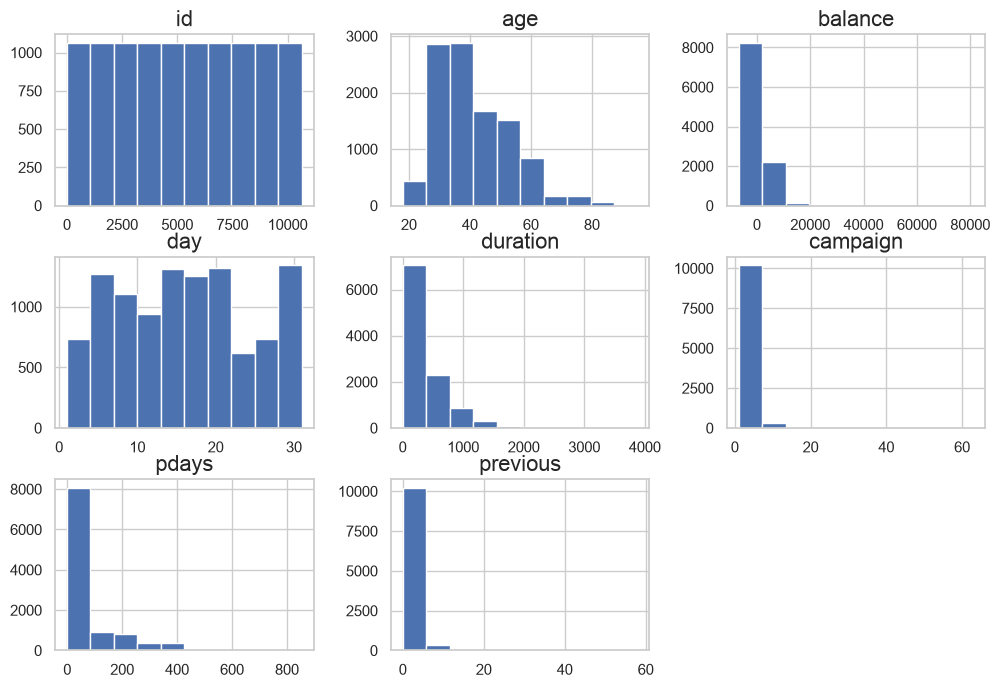

In [125]:
df.hist(figsize=(12,8))

In [126]:
df.corr(numeric_only=True)

,id,age,balance,day,duration,campaign,pdays,previous
id,1.000000,-0.018351,-0.052083,0.042937,-0.459804,0.101147,-0.066993,-0.060385
age,-0.018351,1.000000,0.113850,0.000448,-0.001459,-0.006937,0.003492,0.021585
balance,-0.052083,0.113850,1.000000,0.010562,0.021708,-0.011664,0.020407,0.032856
day,0.042937,0.000448,0.010562,1.000000,-0.018101,0.131814,-0.074064,-0.057324
duration,-0.459804,-0.001459,0.021708,-0.018101,1.000000,-0.037750,-0.028958,-0.029033
campaign,0.101147,-0.006937,-0.011664,0.131814,-0.037750,1.000000,-0.103519,-0.050652
pdays,-0.066993,0.003492,0.020407,-0.074064,-0.028958,-0.103519,1.000000,0.504004
previous,-0.060385,0.021585,0.032856,-0.057324,-0.029033,-0.050652,0.504004,1.000000


The dataset contains demographic, financial, and contact history information for Banco Atlas customers. The objective is to identify which characteristics are associated with a higher probability of subscribing to a term deposit following a marketing campaign.

Missing values are found in the age, marital, and education variables. Since the percentage of missing data is very low, these records can be removed during the data cleaning phase without significantly affecting the dataset.

The target variable (deposit) is almost perfectly balanced between customers who subscribed to the term deposit and those who did not (approximately 49.7% vs. 50.3%).

The dataset population is composed mainly of middle-aged adults.

The balance variable shows a strong positive skew and contains potential outliers, although these may represent customers with high account balances.

The duration variable is also right-skewed, indicating that most phone calls are relatively short.


- 10,642 records
- 18 variables
- 1 record = 1 contacted customer

IDENTIFICATOR =	id
DEMOGRAPHICS =	age, job, marital, education
FINANCIAL =	    balance, default, housing, loan
CAMPAIGN =		contact, day, month, duration, campaign
HISTORY =		pdays, previous, poutcome
OBJECTIVE =		deposit

NaN:
age: 9 
marital: 5
education: 7 

DESCRIBE():
BALANCE 🡺  min -6847 / max 81204	
CAMPAIGN 🡺 max = 63	(number of contacts performed during this campaign and for this client ??) Ok? Too much?
DURATION 🡺 max = 64 min   
PDAYS 🡺    -1 = never contacted before

UNKNOWN VALUES:
Poutcame = 7885
Contact = 2196
Education = 473
Job = 68

POUTCOME:
- UNKNOWN 7885
- FAILURE 1180
- SUCCESS 1065
- OTHER 512

CONTACT:
- cellular     7707
- unknown      2196
- telephone     739	

DEPOSIT = YES / NO balanced 50%

MONTH = max may 2646 / min December 109


# EDA (Exploration Data Analysis)
## 2.0 Reusable Analysis Functions

To ensure consistency throughout the notebook, two reusable functions are defined:

- **analyze_numeric()** → Numerical variables
- **analyze_categorical()** → Categorical variables

Both functions generate standardized tables and visualizations that will be reused across the entire EDA.

In [127]:
# Reusable function for numerical variables


def analyze_numeric(df, variable, target="deposit"):
    """
    Display summary statistics and a boxplot for a numerical variable
    grouped by the target variable.
    """

    missing = df[variable].isna().sum()
    missing_pct = (missing / len(df)) * 100
    unique = df[variable].nunique()

    print("=" * 80)
    print(f"NUMERICAL VARIABLE: {variable.upper()}")
    print("=" * 80)
    print(f"Data type       : {df[variable].dtype}")
    print(f"Missing values  : {missing} ({missing_pct:.2f}%)")
    print(f"Unique values   : {unique}")
    print()


# Summary statistics

    summary = (
        df.groupby(target)[variable]
          .agg(
              Count="count",
              Mean="mean",
              Median="median",
              Std="std",
              Min="min",
              Max="max"
          )
          .round(2)
    )

    display(summary)


# Boxplot


    plt.figure(figsize=(10,6))

    sns.boxplot(
        data=df,
        x=target,
        y=variable,
        hue=target,
        palette=["#1F5C45", "#9FC2A9"],
        legend=False
    )

    plt.title(f"{variable.capitalize()} by {target.capitalize()}")

    plt.xlabel(target.capitalize())

    plt.ylabel(variable.capitalize())

    plt.tight_layout()

    plt.show()

In [128]:
# Reusable function for categorical variables


def analyze_categorical(df, variable, target="deposit"):
    """
    Display percentage table and normalized stacked bar chart
    for a categorical variable.
    """

    missing = df[variable].isna().sum()
    missing_pct = (missing / len(df)) * 100
    unique = df[variable].nunique()

    print("=" * 80)
    print(f"CATEGORICAL VARIABLE: {variable.upper()}")
    print("=" * 80)
    print(f"Data type            : {df[variable].dtype}")
    print(f"Missing values       : {missing} ({missing_pct:.2f}%)")
    print(f"Unique categories    : {unique}")
    print()


# Percentage table


    percentage_table = (
        pd.crosstab(
            df[variable],
            df[target],
            normalize="index"
        ) * 100
    ).round(2)

    display(percentage_table)


# 100% Stacked Bar Chart


    ax = percentage_table.plot(
        kind="bar",
        stacked=True,
        figsize=(11,6),
       color=["#1F5C45", "#9FC2A9"]
    )

    plt.title(f"{variable.capitalize()} vs {target.capitalize()}")

    plt.xlabel(variable.capitalize())

    plt.ylabel("Percentage (%)")

    plt.legend(title=target.capitalize(),
               bbox_to_anchor=(1.05, 1),
               loc = "upper left")

    plt.xticks(rotation=45, ha="right")


    plt.tight_layout()

    plt.show()

## 2.1 Demographic Variables

This section explores the demographic characteristics of the bank's customers and their relationship with the target variable (`deposit`).

The objective is to identify demographic patterns that may support future customer segmentation analyses while providing a descriptive overview for subsequent business analyses.

### Research Question AGE

**Does customer age differ between clients who subscribed to a term deposit and those who did not?**

Age is one of the most relevant demographic variables in customer segmentation. This exploratory analysis compares the age distribution of both customer groups without drawing causal conclusions.

NUMERICAL VARIABLE: AGE
Data type       : float64
Missing values  : 9 (0.08%)
Unique values   : 76



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5347,40.84,39.0,10.3,18.0,89.0
yes,5286,41.67,38.0,13.5,18.0,95.0


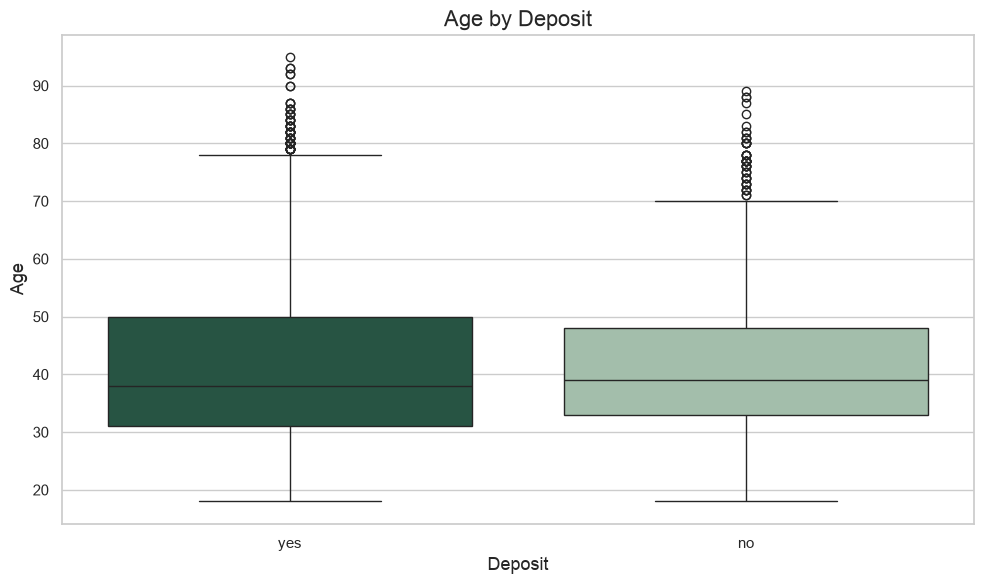

In [129]:
# AGE

analyze_numeric(df, "age")

### Interpretation

The summary statistics and boxplot provide an overview of the age distribution for customers who subscribed to a term deposit and those who did not.

Special attention should be paid to:

- Differences in median age.
- Variability within each customer group.
- Presence of potential outliers.
- Overall similarity or separation between both distributions.

These observations are descriptive and should be validated in subsequent business analyses.

### Business Implication

Age is expected to be one of the main demographic variables for customer profiling.

This exploratory analysis provides an initial understanding of customer behaviour and may support later segmentation studies performed by the Customer Profile Analytics team.

### Research Question JOB

**Does the customer's occupation influence the likelihood of subscribing to a term deposit?**

Occupation is an important demographic characteristic that may reflect income stability, financial behaviour and purchasing power.

The following analysis compares the percentage of customers who subscribed to a term deposit within each occupational category.

CATEGORICAL VARIABLE: JOB
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 12



deposit,no,yes
job,,
admin.,50.66,49.34
blue-collar,61.31,38.69
entrepreneur,60.06,39.94
housemaid,57.59,42.41
management,46.83,53.17
retired,31.66,68.34
self-employed,51.80,48.20
services,58.12,41.88
student,24.01,75.99


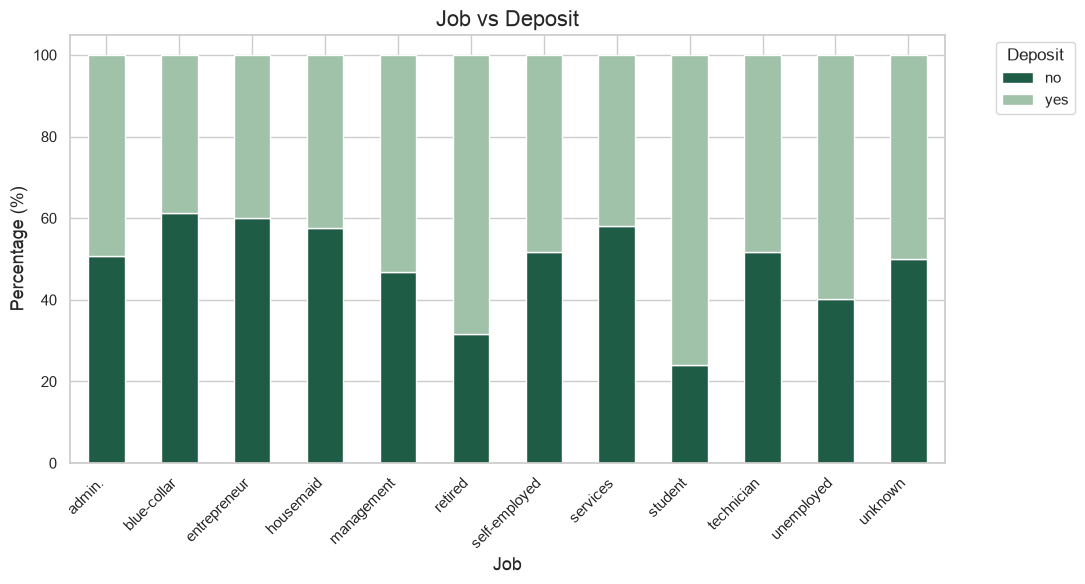

In [130]:
# JOB

analyze_categorical(df, "job")

### Interpretation

The normalized percentage chart allows comparison between occupational groups regardless of their size.

The analysis highlights whether some professions appear to have a higher proportion of customers subscribing to a term deposit.

At this stage, the objective is only to identify potential patterns.

### Business Implication

Occupation may become an important segmentation variable for identifying customer profiles with different financial behaviours and product preferences.

### Research Question MARITAL

**Is marital status associated with different subscription behaviour?**

Marital status may influence saving habits, financial planning and household financial decisions.

This exploratory analysis compares subscription percentages across different marital groups.

CATEGORICAL VARIABLE: MARITAL
Data type            : str
Missing values       : 5 (0.05%)
Unique categories    : 3



deposit,no,yes
marital,,
divorced,49.72,50.28
married,54.31,45.69
single,43.36,56.64


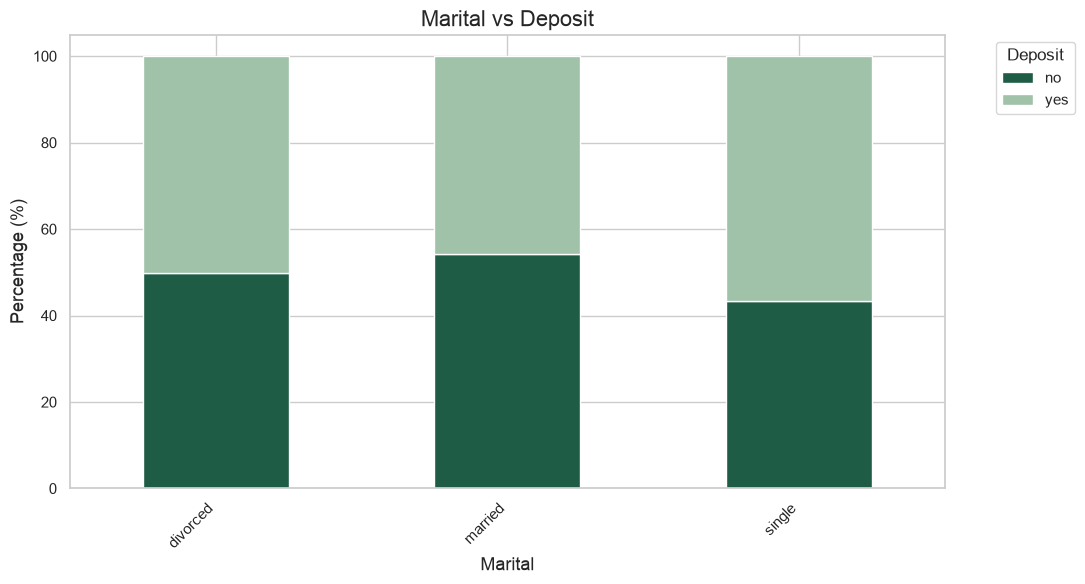

In [131]:
# MARITAL

analyze_categorical(df, "marital")

### Interpretation

The comparison identifies possible differences in subscription rates among marital status categories.

Any observed differences should be considered exploratory and will require further statistical validation.

### Business Implication

Marital status may contribute to future customer segmentation strategies and demographic profiling.

### Research Question EDUCATION

**Does the customer's education level show different subscription patterns?**

Education level may be associated with financial literacy, investment preferences and product adoption.

This analysis explores the relationship between education level and term deposit subscription.

CATEGORICAL VARIABLE: EDUCATION
Data type            : str
Missing values       : 7 (0.07%)
Unique categories    : 4



deposit,no,yes
education,,
primary,58.35,41.65
secondary,53.05,46.95
tertiary,43.46,56.54
unknown,46.72,53.28


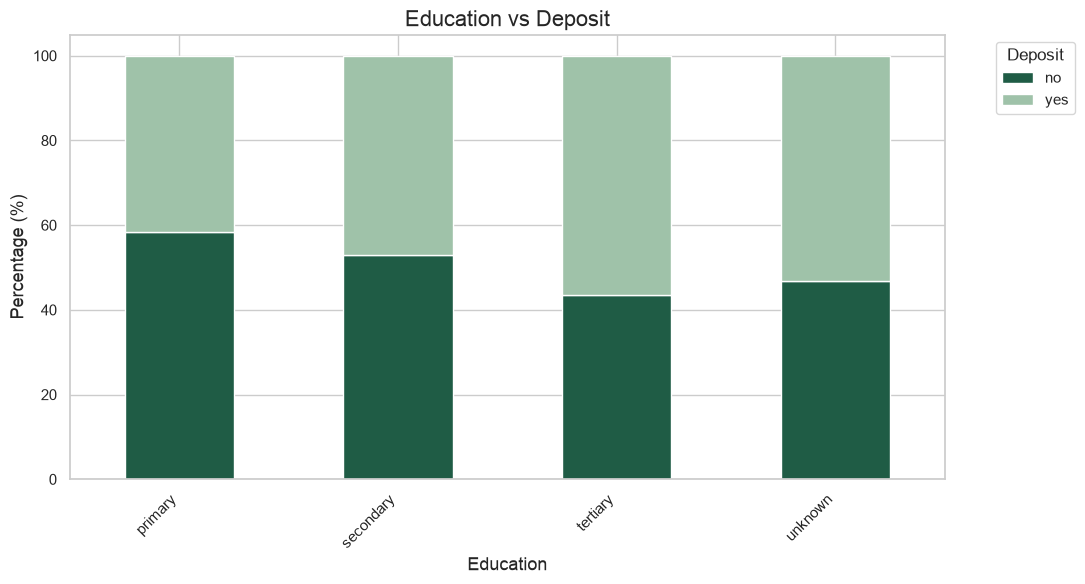

In [132]:
# EDUCATION

analyze_categorical(df, "education")

### Interpretation

The percentage distribution provides an overview of subscription behaviour across different education levels.

Observed differences may indicate potential customer segments worthy of further investigation.

### Business Implication

Education level may become a useful explanatory variable in future customer segmentation and predictive modelling analyses.

### Relevance for Business Analysis and Group Question

The analyses presented in this section provide an exploratory overview of the main demographic characteristics of the bank's customers.

These findings will support subsequent customer segmentation analyses and help identify demographic profiles potentially associated with different subscription behaviours.

## 2.2 Financial Variables

Financial variables describe the customer's financial situation and represent one of the most important sources of information for understanding customer behaviour and assessing potential financial risk.

The objective of this section is to explore these variables individually and identify preliminary patterns related to the target variable (`deposit`).

These analyses are exploratory only and do not imply causal relationships.

### Research Question BALANCE

**Do customers with different account balances show different subscription behaviour?**

The account balance is one of the most relevant financial indicators in the dataset and may provide valuable insights into customer saving behaviour and financial capacity.

NUMERICAL VARIABLE: BALANCE
Data type       : int64
Missing values  : 0 (0.00%)
Unique values   : 3703



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5353,1272.16,418.0,2899.42,-6847,66653
yes,5289,1804.27,733.0,3501.10,-3058,81204


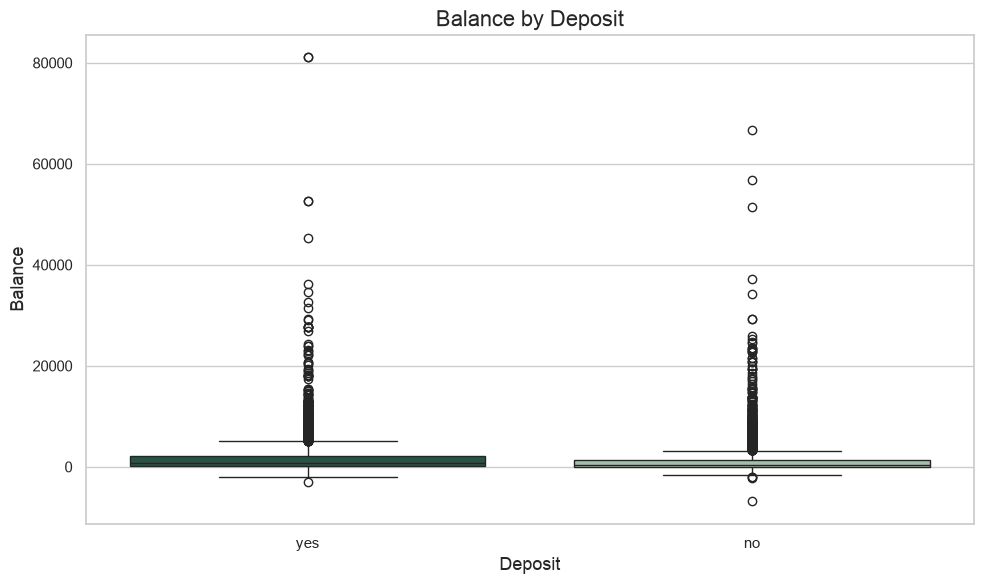

In [133]:
# BALANCE

analyze_numeric(df, "balance")

### Interpretation

The account balance distribution provides an overview of customers' financial capacity.

When analysing the boxplot and summary statistics, particular attention should be paid to:

- Median balance.
- Distribution variability.
- Presence of extreme values.
- Differences between customers who subscribed to a term deposit and those who did not.

Large balance values should not automatically be considered outliers, as they may correspond to high-value customers.

### Business Implication

Account balance is expected to be one of the most relevant financial variables throughout the project.

This variable will be particularly important for future analyses related to customer financial behaviour and credit risk.

### Research Question DEFAULT

**Does credit default status appear to be associated with different subscription behaviour?**

Customers with previous credit defaults may present different financial behaviours and different responses to financial products.

CATEGORICAL VARIABLE: DEFAULT
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 2



deposit,no,yes
default,,
no,50.06,49.94
yes,66.45,33.55


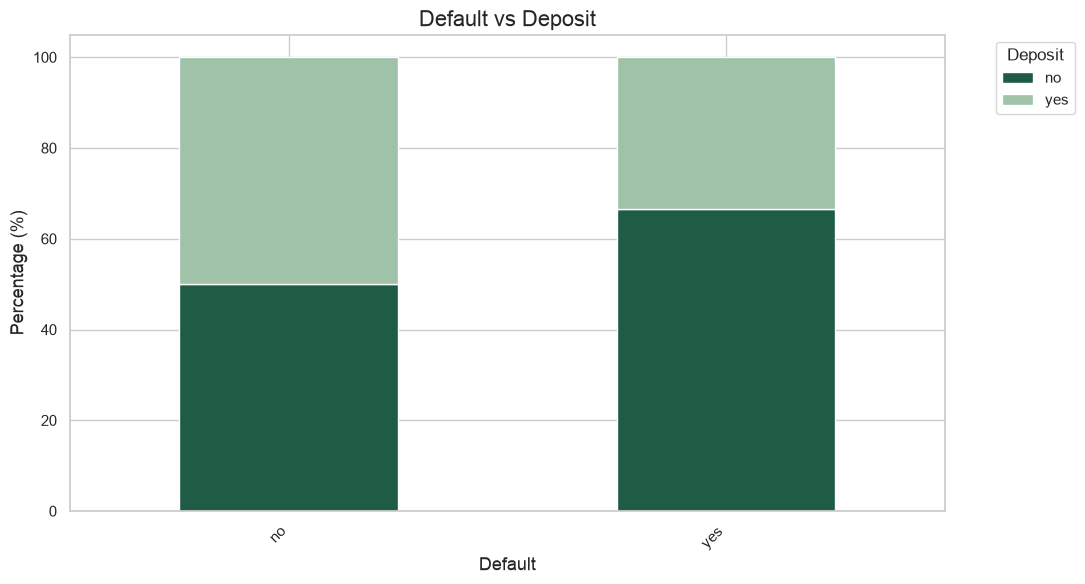

In [134]:
# DEFAULT


analyze_categorical(df, "default")

### Interpretation

This analysis compares the percentage of customers subscribing to a term deposit according to their credit default status.

Observed differences represent exploratory patterns only and should be interpreted cautiously.

### Business Implication

Credit default may become an important explanatory variable for future analyses involving customer financial stability and credit risk.

### Research Question HOUSING

**Does having a housing loan influence customer subscription behaviour?**

Housing loans represent long-term financial commitments and may influence customers' saving capacity.

CATEGORICAL VARIABLE: HOUSING
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 2



deposit,no,yes
housing,,
no,40.74,59.26
yes,61.16,38.84


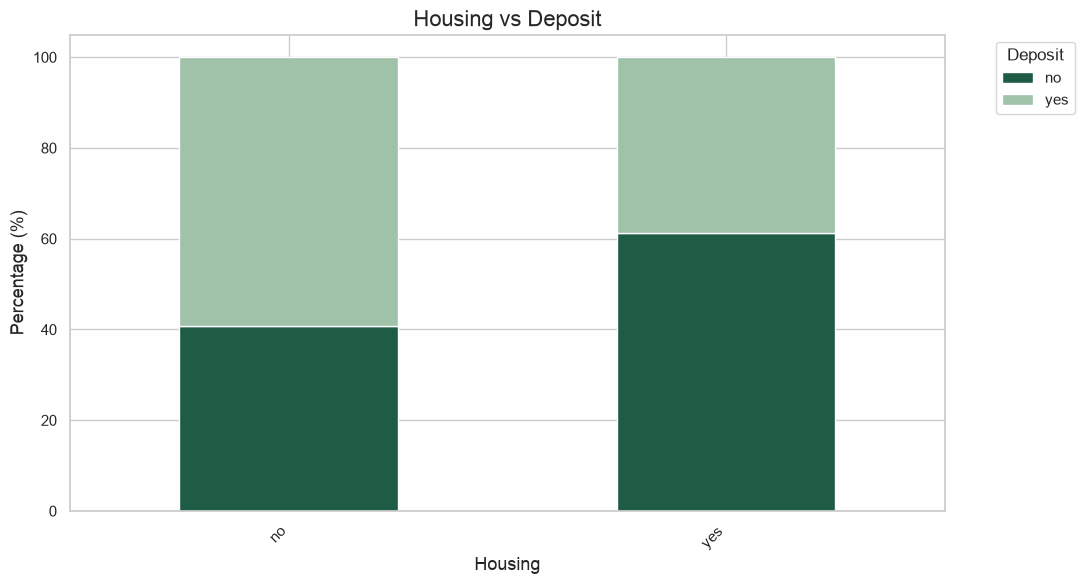

In [135]:
# HOUSING

analyze_categorical(df, "housing")

### Interpretation

The analysis compares subscription percentages between customers with and without a housing loan.

The objective is to identify possible behavioural differences without establishing causal relationships.

### Business Implication

Housing loans may help identify different customer financial profiles and may contribute to later business segmentation analyses.

### Research Question LOAN

**Does having a personal loan influence the likelihood of subscribing to a term deposit?**

Personal loans may affect disposable income and customers' saving decisions.

CATEGORICAL VARIABLE: LOAN
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 2



deposit,no,yes
loan,,
no,48.17,51.83
yes,64.72,35.28


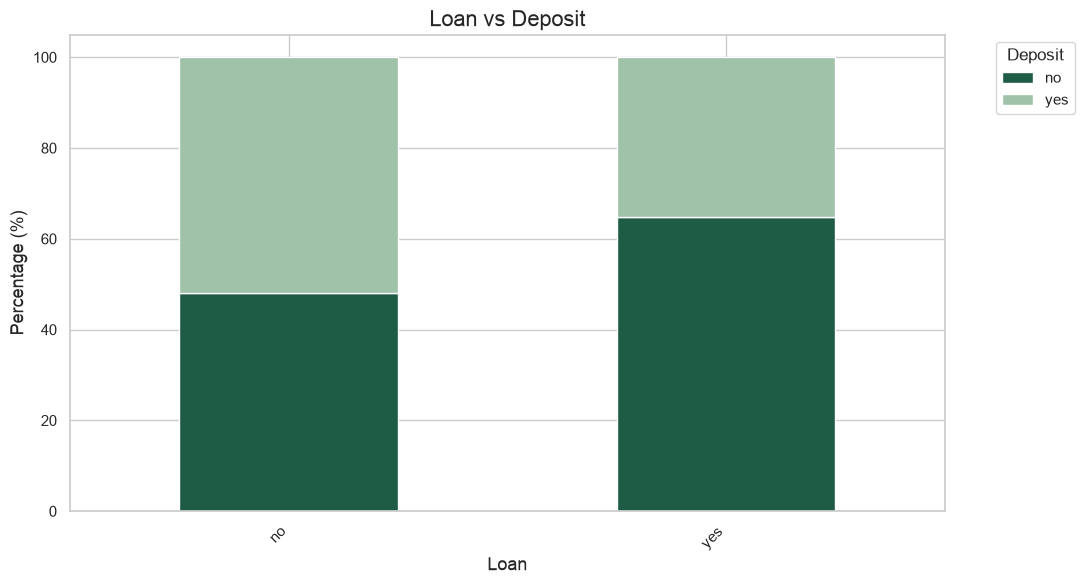

In [136]:
# LOAN

analyze_categorical(df, "loan")

### Interpretation

The percentage comparison allows an initial exploration of customer subscription behaviour according to personal loan status.

Observed differences should be considered descriptive rather than explanatory.

### Business Implication

Personal loans may become an additional explanatory variable when analysing customer financial behaviour and future credit risk.

### Relevance for Business Analysis and Group Question

The financial variables explored in this section provide an initial overview of customers' financial characteristics.

These findings establish the foundation for future analyses related to financial behaviour, customer solvency and credit risk assessment.

### 2.2.1 Exploratory Financial Relationships

After analysing each financial variable individually, this section explores the relationship between the main financial variables.

The objective is to identify preliminary patterns that may be useful for future financial risk analysis.

These observations are exploratory only and should not be interpreted as causal relationships.

### Research Question

**Do customers with lower account balances show a higher incidence of credit default?**

This exploratory analysis compares the account balance distribution of customers according to their credit default status.

,Count,Mean,Median,Std,Min,Max
default,,,,,,
no,10487,1560.42,571.0,3239.50,-3058,81204
yes,155,-74.02,0.0,854.14,-6847,5249


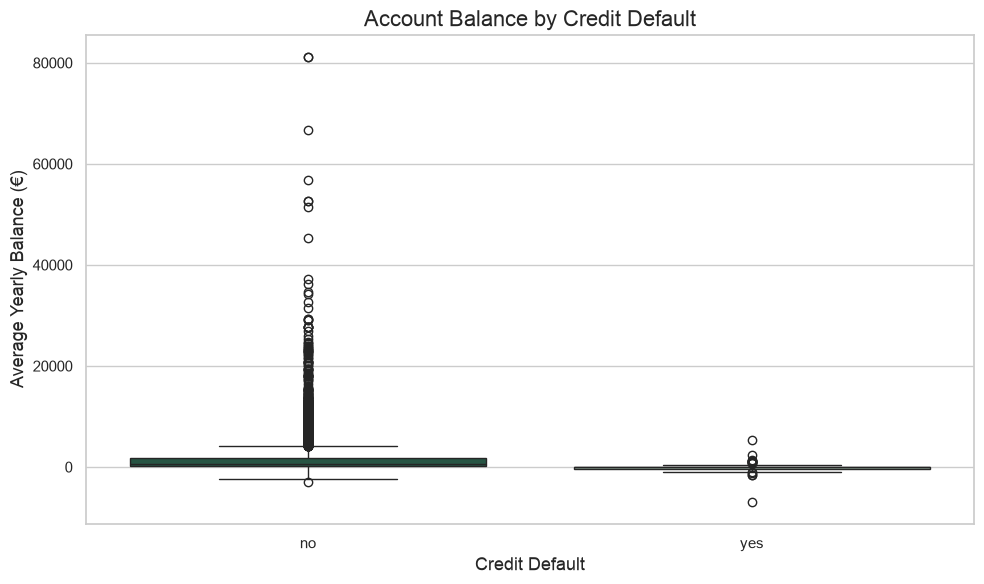

In [137]:
# ============================================================
# BALANCE vs DEFAULT
# ============================================================

summary = (
    df.groupby("default")["balance"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std="std",
          Min="min",
          Max="max"
      )
      .round(2)
)

display(summary)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="default",
    y="balance",
    hue="default",
    palette=["#1F5C45", "#9FC2A9"],
    legend=False
)

plt.title("Account Balance by Credit Default")

plt.xlabel("Credit Default")

plt.ylabel("Average Yearly Balance (€)")

plt.tight_layout()

plt.show()

### Interpretation

This comparison explores whether customers with previous credit defaults present different balance distributions.

Special attention should be paid to:

- Median balance.
- Distribution variability.
- Presence of extreme values.
- Overall separation between both groups.

No conclusions regarding causality should be drawn at this stage.

### Business Implication

This exploratory relationship will be particularly relevant during the Financial & Credit Risk analysis, where the relationship between customer balance and default risk will be investigated in greater detail.

### Research Question

**Does having a personal loan appear to be associated with credit default?**

Customers with active personal loans may exhibit different financial characteristics compared with customers without personal loans.

This exploratory analysis compares default proportions between both groups.

default,no,yes
loan,,
no,98.91,1.09
yes,96.06,3.94


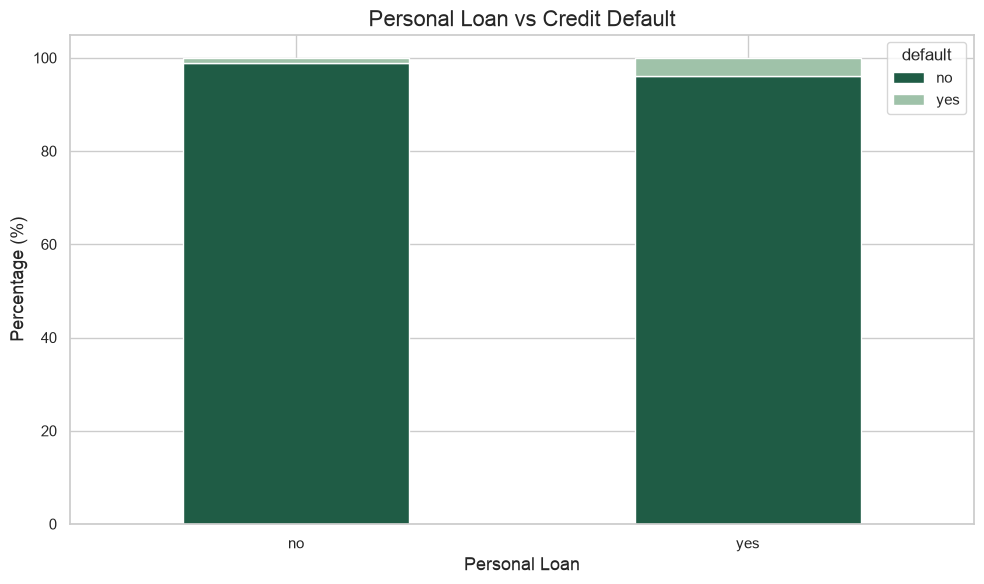

In [138]:
# ============================================================
# LOAN vs DEFAULT
# ============================================================

loan_default = (
    pd.crosstab(
        df["loan"],
        df["default"],
        normalize="index"
    ) * 100
).round(2)

display(loan_default)

loan_default.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color= ["#1F5C45", "#9FC2A9"]
)

plt.title("Personal Loan vs Credit Default")

plt.xlabel("Personal Loan")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Interpretation

The percentage comparison allows an initial exploration of the relationship between personal loans and credit default.

Observed differences should be considered descriptive and may require further statistical analysis.

### Business Implication

Understanding the relationship between personal loans and default may support future analyses related to customer financial stability.

### Research Question

**Does having a housing loan appear to be associated with credit default?**

Housing loans represent long-term financial commitments and may influence customer financial risk.

This analysis compares default percentages between customers with and without housing loans.

default,no,yes
housing,,
no,98.67,1.33
yes,98.39,1.61


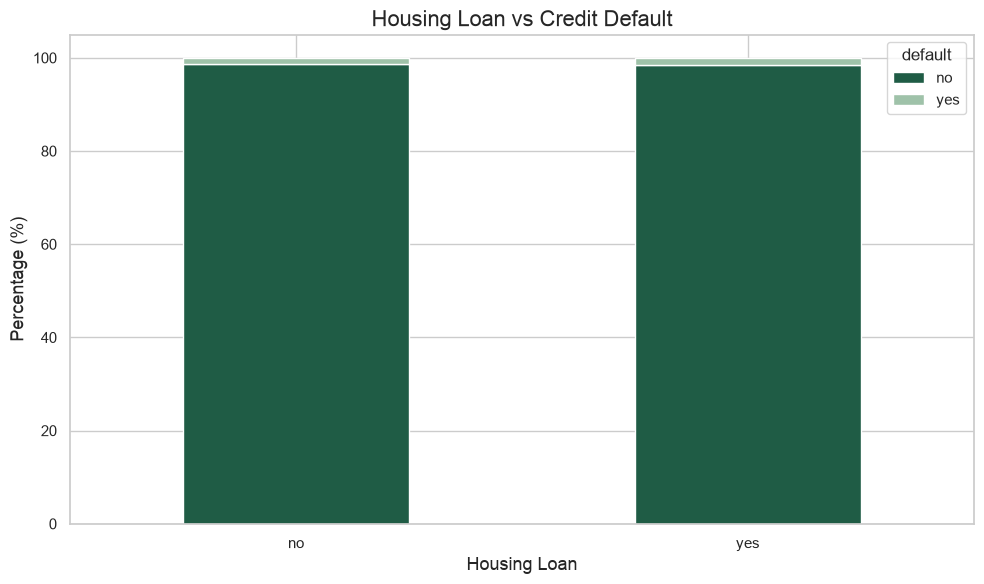

In [139]:
# ============================================================
# HOUSING vs DEFAULT
# ============================================================

housing_default = (
    pd.crosstab(
        df["housing"],
        df["default"],
        normalize="index"
    ) * 100
).round(2)

display(housing_default)

housing_default.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#1F5C45", "#9FC2A9"]
)

plt.title("Housing Loan vs Credit Default")

plt.xlabel("Housing Loan")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Interpretation

This exploratory analysis compares the proportion of customers in default according to housing loan status.

Any observed differences should be considered preliminary and require further investigation.

### Business Implication

Housing loans may represent an important financial characteristic when analysing customer credit risk profiles.

### Research Question

**Do customers with personal loans present different account balance distributions?**

Personal loans may influence customers' available financial resources and saving capacity.

This exploratory analysis compares the account balance distributions between customers with and without personal loans.

,Count,Mean,Median,Std,Min,Max
loan,,,,,,
no,9270,1640.20,606.0,3326.89,-2049,81204
yes,1372,836.76,296.0,2291.92,-6847,51439


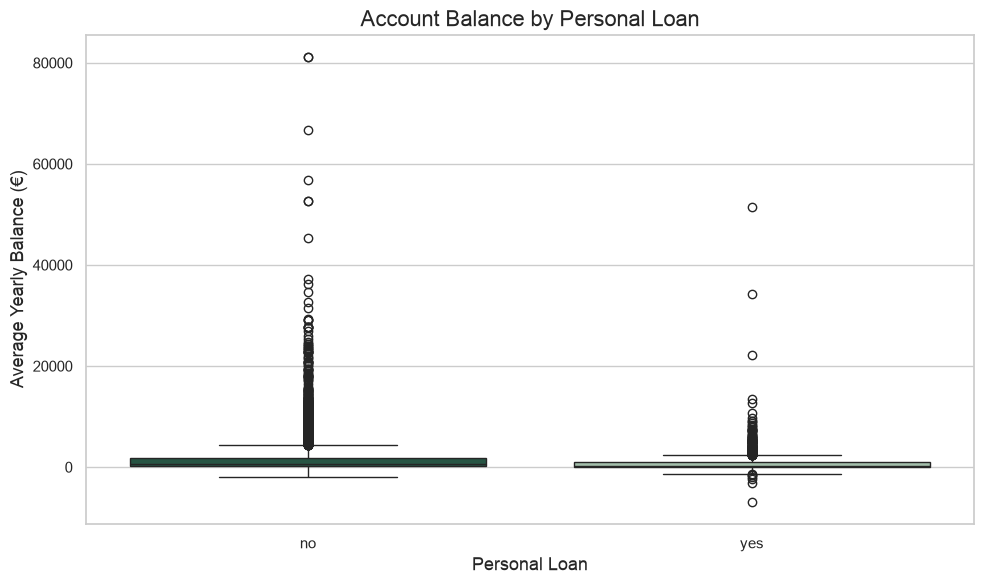

In [140]:
# ============================================================
# BALANCE vs LOAN
# ============================================================

summary = (
    df.groupby("loan")["balance"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std="std",
          Min="min",
          Max="max"
      )
      .round(2)
)

display(summary)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="loan",
    y="balance",
    hue="loan",
    palette=["#1F5C45", "#9FC2A9"],
    legend=False
)

plt.title("Account Balance by Personal Loan")

plt.xlabel("Personal Loan")

plt.ylabel("Average Yearly Balance (€)")

plt.tight_layout()

plt.show()

### Interpretation

This comparison explores whether customers with personal loans exhibit different account balance distributions compared with customers without personal loans.

The analysis focuses on:

- Median account balance.
- Distribution variability.
- Presence of extreme values.
- Overall differences between both customer groups.

These findings are exploratory and should not be interpreted as evidence of a causal relationship.

### Business Implication

Understanding the relationship between personal loans and customer balances may contribute to future analyses of customer financial profiles and credit risk.

### Section Summary

The analyses performed in this section provide an initial overview of the financial characteristics of the bank's customers.

The observed patterns establish a foundation for subsequent analyses related to:

- Customer financial behaviour.
- Credit risk assessment.
- Customer solvency.
- Business decision-making.

These exploratory findings will support the future work of the Financial & Credit Risk Analytics team.

## 2.3 Campaign Variables

Campaign-related variables describe how the bank interacted with customers during the marketing campaign.

The purpose of this section is to explore these variables and identify descriptive patterns associated with the target variable (`deposit`).

The analyses presented here are exploratory only and should not be interpreted as recommendations for marketing strategies.

### Research Question DURATION

**Do customers who subscribed to a term deposit tend to have different call durations?**

Call duration may reflect the level of customer engagement during the campaign.

This analysis compares the distribution of call duration between customers who subscribed and those who did not.

NUMERICAL VARIABLE: DURATION
Data type       : int64
Missing values  : 0 (0.00%)
Unique values   : 1425



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5353,221.99,162.0,208.69,2,3284
yes,5289,537.29,426.0,392.53,8,3881


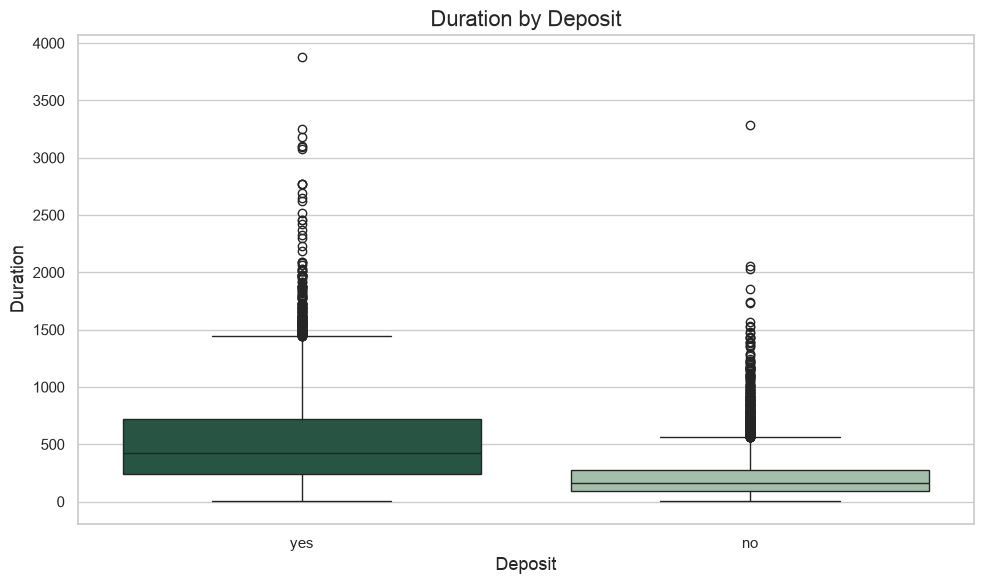

In [141]:
# DURATION

analyze_numeric(df, "duration")

### Interpretation

The comparison explores whether call duration differs between customers who subscribed to a term deposit and those who did not.

Special attention should be paid to:

- Median duration.
- Distribution variability.
- Presence of extreme values.
- Overall differences between both groups.

These findings are descriptive and do not imply causality.

### Business Implication

Call duration may provide useful contextual information when analysing customer interaction patterns during the campaign.

Any operational interpretation should be performed in future business analyses.

### Research Question CAMPAIGN

**Does the number of campaign contacts differ between subscribers and non-subscribers?**

This exploratory analysis compares the number of contacts performed during the campaign for both customer groups.

NUMERICAL VARIABLE: CAMPAIGN
Data type       : int64
Missing values  : 0 (0.00%)
Unique values   : 36



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5353,2.85,2.0,3.25,1,63
yes,5289,2.14,2.0,1.92,1,32


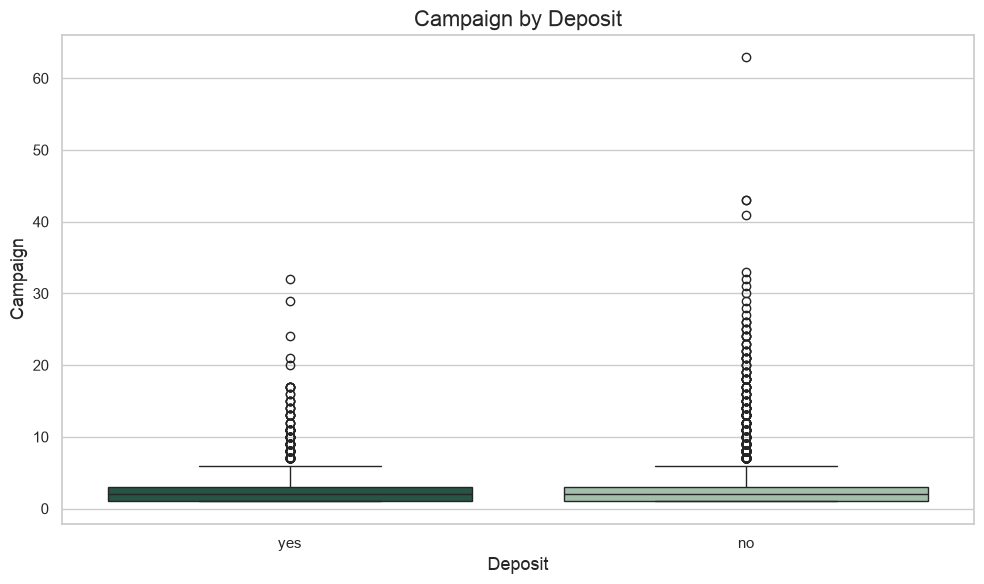

In [142]:
# CAMPAIGN

analyze_numeric(df, "campaign")

### Interpretation

The comparison provides an overview of the distribution of campaign contacts across customer groups.

Observed differences should be interpreted as descriptive findings only.

### Business Implication

The number of campaign contacts may represent an important operational variable for understanding customer interaction during the campaign.

### Research Question CONTACT

**Does the communication channel appear to be associated with different subscription rates?**

Customers were contacted through different communication channels.

This exploratory analysis compares subscription percentages across communication methods.

CATEGORICAL VARIABLE: CONTACT
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 3



deposit,no,yes
contact,,
cellular,43.31,56.69
telephone,47.23,52.77
unknown,75.87,24.13


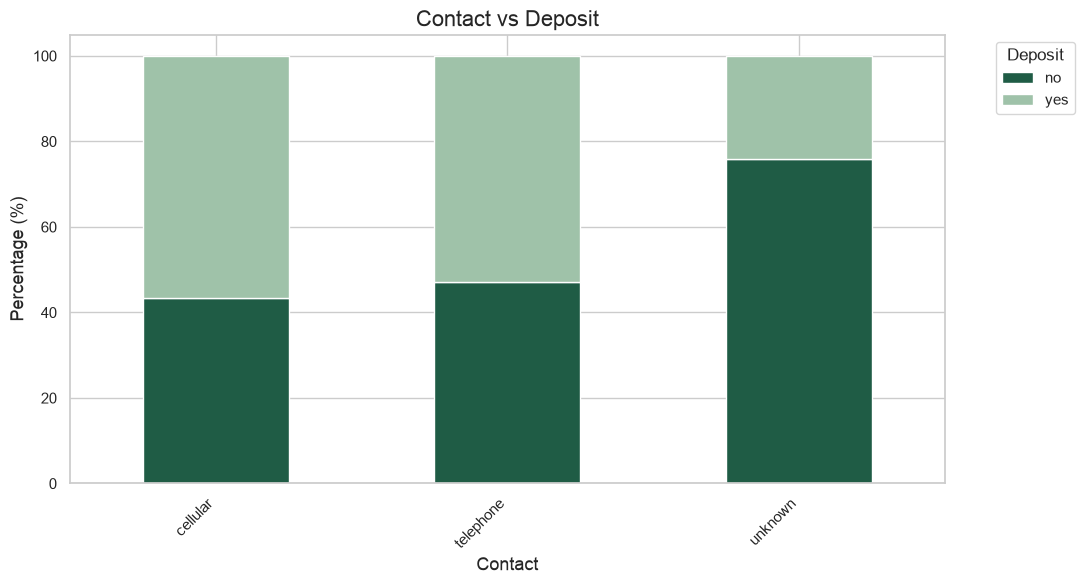

In [143]:
# CONTACT

analyze_categorical(df, "contact")

### Interpretation

The normalized percentage chart compares subscription behaviour across communication channels.

The objective is to identify descriptive differences without establishing causal relationships.

### Business Implication

Communication channels may contribute to understanding customer interaction patterns during the campaign.

### Research Question MONTH

**Are there seasonal differences in term deposit subscriptions?**

The month of customer contact may reveal seasonal patterns in subscription behaviour.

This exploratory analysis compares subscription percentages across different months.

CATEGORICAL VARIABLE: MONTH
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 12



deposit,no,yes
month,,
apr,35.02,64.98
aug,52.55,47.45
dec,8.26,91.74
feb,40.88,59.12
jan,56.57,43.43
jul,56.12,43.88
jun,53.49,46.51
mar,9.49,90.51
may,65.04,34.96


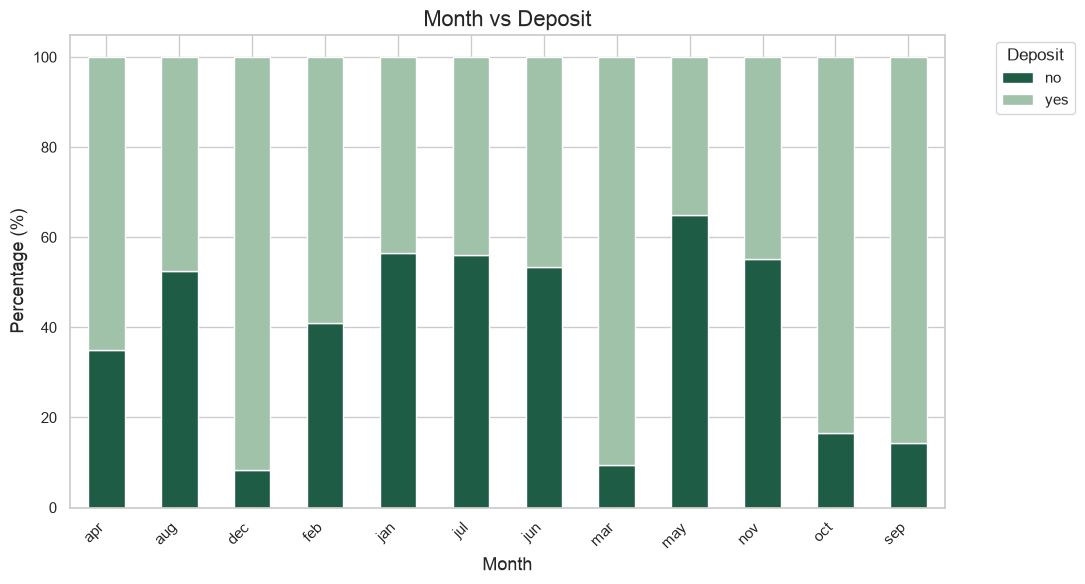

In [144]:
# MONTH

analyze_categorical(df, "month")

### Interpretation

The comparison provides an overview of customer subscription behaviour throughout the different months included in the campaign.

Observed differences represent exploratory patterns and should be interpreted with caution.

### Business Implication

Seasonal patterns may become relevant when interpreting customer behaviour across different campaign periods.

### Relevance for Business Analysis

The campaign variables explored in this section provide contextual information about how customer interactions were conducted.

Although no marketing recommendations are drawn at this stage, these exploratory analyses provide useful background information for future business interpretation.

## 2.4 Previous Campaign Variables

This section explores the variables describing customers' interactions in previous marketing campaigns.

Understanding previous campaign history may provide valuable context regarding customer behaviour and previous responses to marketing activities.

The analyses presented in this section are descriptive and exploratory only.

### Research Question PREVIOUS

**Do customers with previous marketing contacts show different subscription behaviour?**

The variable `previous` indicates the number of contacts performed before the current campaign.

This analysis explores whether customers with previous interactions exhibit different subscription patterns.

NUMERICAL VARIABLE: PREVIOUS
Data type       : int64
Missing values  : 0 (0.00%)
Unique values   : 34



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5353,0.54,0.0,2.02,0,41
yes,5289,1.17,0.0,2.55,0,58


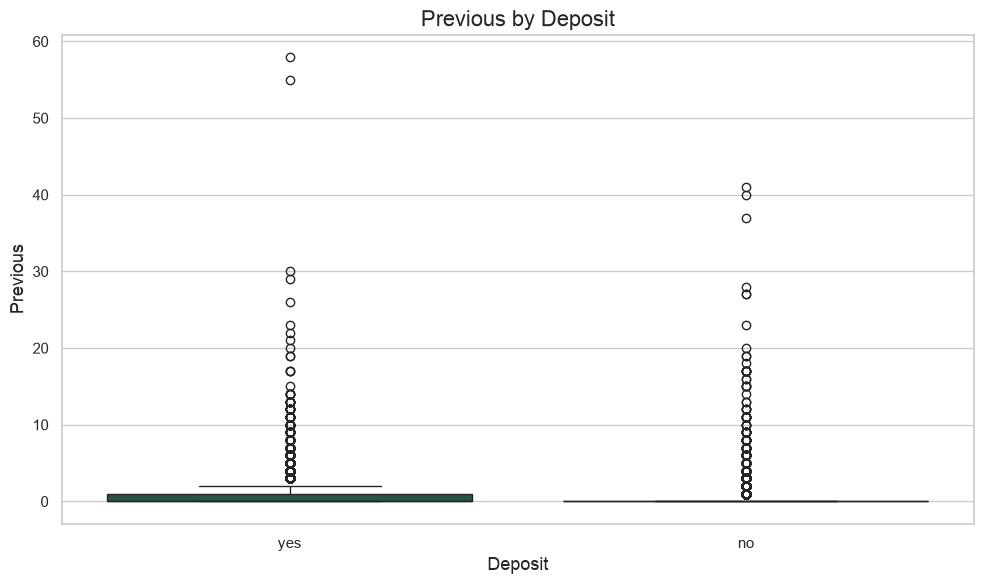

In [145]:
# PREVIOUS

analyze_numeric(df, "previous")

### Interpretation

The distribution of previous contacts provides an overview of customers' prior interactions with the bank.

The analysis focuses on:

- Number of previous contacts.
- Distribution variability.
- Potential differences between subscribers and non-subscribers.

Observed differences are exploratory and should not be interpreted as causal relationships.

### Business Implication

Previous customer interactions may provide useful context when analysing customer engagement and historical behaviour.

### Research Question PDAYS

**Does the time elapsed since the previous campaign appear to influence subscription behaviour?**

The variable `pdays` represents the number of days since the customer was last contacted in a previous campaign.

This analysis explores whether the elapsed time differs between customers who subscribed and those who did not.

NUMERICAL VARIABLE: PDAYS
Data type       : int64
Missing values  : 0 (0.00%)
Unique values   : 469



,Count,Mean,Median,Std,Min,Max
deposit,,,,,,
no,5353,35.64,-1.0,96.02,-1,826
yes,5289,68.70,-1.0,118.82,-1,854


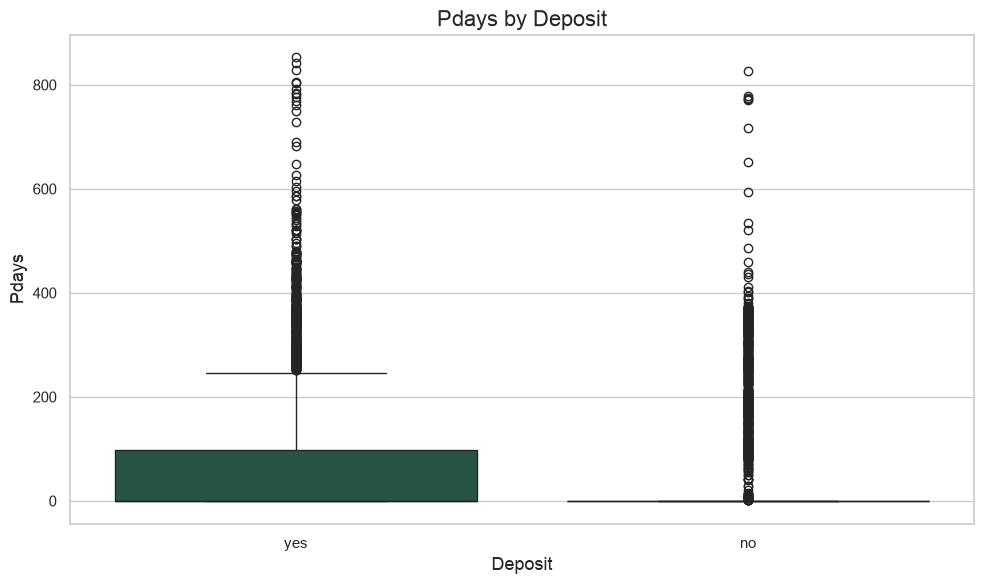

In [146]:
# PDAYS

analyze_numeric(df, "pdays")

### Interpretation

The comparison explores the distribution of elapsed time since the previous campaign.

Special attention should be paid to:

- Median elapsed time.
- Distribution variability.
- Presence of extreme values.
- Differences between customer groups.

These findings are descriptive only.

### Business Implication

The elapsed time since previous customer contact may become relevant when analysing historical customer engagement.

### Research Question POUTCOME

**Does the outcome of the previous marketing campaign appear to be associated with current subscription behaviour?**

The variable `poutcome` describes the outcome of the customer's previous campaign.

This analysis compares current subscription percentages across previous campaign outcomes.

CATEGORICAL VARIABLE: POUTCOME
Data type            : str
Missing values       : 0 (0.00%)
Unique categories    : 4



deposit,no,yes
poutcome,,
failure,47.63,52.37
other,40.04,59.96
success,8.17,91.83
unknown,57.06,42.94


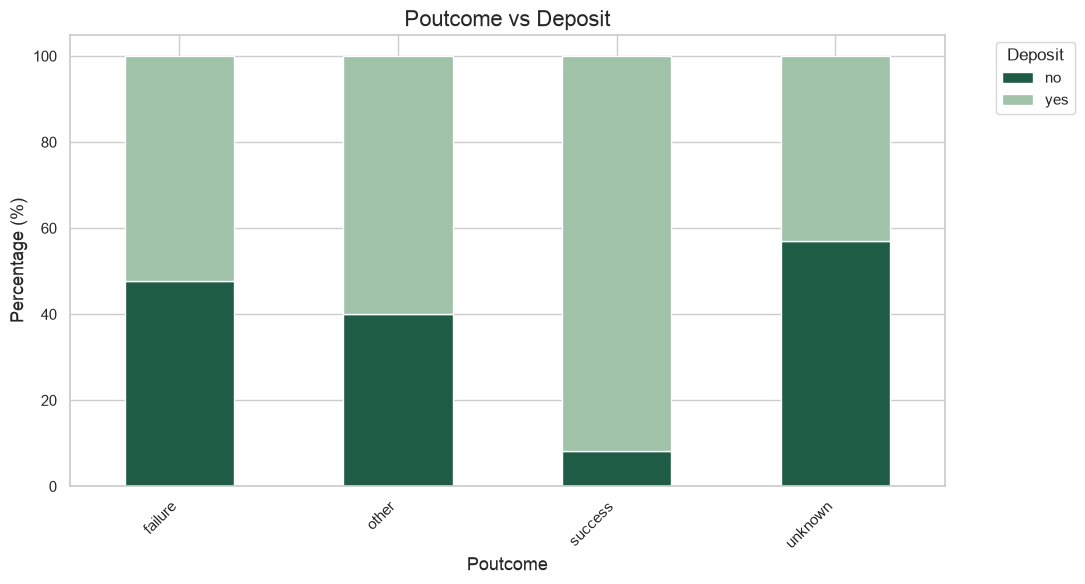

In [147]:
# POUTCOME

analyze_categorical(df, "poutcome")

### Interpretation

The comparison provides an overview of current subscription behaviour according to the outcome of previous campaigns.

Observed differences may indicate behavioural patterns that deserve further investigation in later analyses.

### Business Implication

Previous campaign outcomes may provide valuable contextual information when analysing customer behaviour across multiple marketing campaigns.

### Relevance for Business Analysis

The variables explored in this section describe customers' historical interactions with previous campaigns.

Although this analysis remains exploratory, these variables may contribute to a better understanding of customer behaviour and historical engagement patterns in subsequent stages of the project.

## 2.5 Correlation Analysis

Correlation analysis helps identify linear relationships between numerical variables.

The objective of this section is to provide an overview of the strongest relationships within the dataset and identify variables that may deserve further investigation in subsequent stages of the project.

Only numerical variables are included in this analysis.

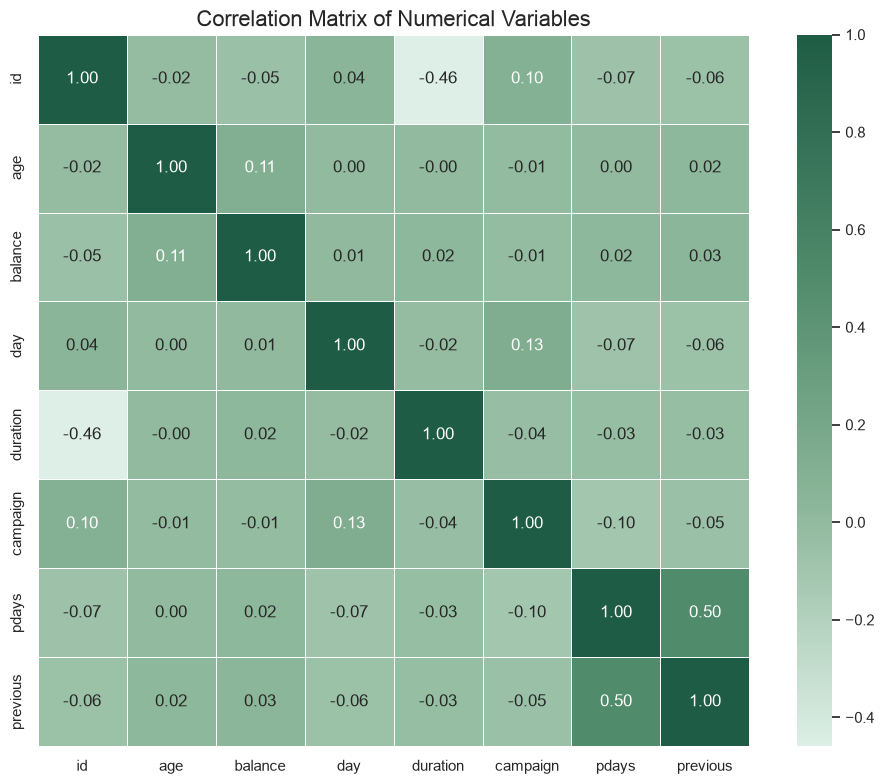

In [148]:
# CORRELATION MATRIX

numerical_df = df.select_dtypes(include=["number"])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap = sns.blend_palette(
    ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
    as_cmap=True),
    #vmin=-0.3,
    #vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

### Interpretation

The correlation matrix provides an overview of the linear relationships between numerical variables.

Correlation coefficients close to **+1** indicate a strong positive relationship, while values close to **-1** indicate a strong negative relationship.

Values close to **0** suggest weak or no linear association.

It is important to note that correlation does not imply causation.

In [149]:
# CORRELATION RANKING

corr_pairs = (
    correlation_matrix
        .unstack()
        .drop_duplicates()
        .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(15))

pdays    previous    0.504004
day      campaign    0.131814
age      balance     0.113850
id       campaign    0.101147
         day         0.042937
balance  previous    0.032856
         duration    0.021708
age      previous    0.021585
balance  pdays       0.020407
         day         0.010562
age      pdays       0.003492
         day         0.000448
         duration   -0.001459
         campaign   -0.006937
balance  campaign   -0.011664
dtype: float64

### Business Implication

The correlation analysis helps identify numerical variables that may deserve further investigation during later stages of the project.

Variables showing stronger relationships may become useful candidates for feature selection, predictive modelling or business interpretation.

Categorical variables require different statistical techniques (such as contingency analysis or association measures) and are therefore not included in this correlation matrix.

## 2.6 Exploratory Insights and Next Steps

The Exploratory Data Analysis (EDA) provided a comprehensive understanding of the banking dataset and revealed several patterns that will support the subsequent stages of the project.

The following insights summarize the most relevant observations obtained during this exploratory phase.

---

### Data Quality Insights

- The dataset presents a high level of completeness, with only a limited number of missing values affecting a small subset of variables.

- Most variables exhibit consistent data quality and are suitable for subsequent analytical stages.

- Several categorical variables contain the category **"unknown"**, which should be carefully evaluated during the Data Cleaning phase to determine the most appropriate treatment.

- Numerical variables such as **balance**, **duration** and **campaign** display skewed distributions and the presence of extreme values. Based on the exploratory analysis, these observations appear plausible within a banking environment and should not automatically be considered data errors.

---

### Customer Profile Insights

- Customer age shows only moderate differences between subscribers and non-subscribers, suggesting that age alone may not fully explain deposit subscription behaviour.

- Occupation appears to influence customer behaviour, with profiles such as retired customers and students showing relatively higher subscription rates compared with several other occupational groups.

- Customers with tertiary education present higher subscription proportions than customers with primary education, indicating that education level may contribute to future customer segmentation analyses.

- Subscription behaviour also varies across marital status categories, suggesting that demographic variables may become useful explanatory features during later business analyses.

---

### Financial Insights

- Customers who subscribed to a term deposit generally present higher account balances than customers who did not subscribe.

- Customers with previous credit default records appear to show lower subscription rates, suggesting that financial variables deserve further investigation during the Financial & Credit Risk analysis.

- Exploratory comparisons between **balance**, **loan**, **housing** and **default** reveal behavioural patterns that justify deeper analysis in the subsequent business stage.

- The financial variables analysed in this section provide a strong foundation for answering the business question assigned to the Financial & Credit Risk Analytics team.

---

### Campaign Insights

- Campaign-related variables reveal noticeable differences between customer groups and provide valuable context regarding customer interactions throughout the marketing campaign.

- Variables such as **duration**, **campaign**, **contact** and **month** describe operational characteristics of the campaign and may contribute to future business interpretation, although no marketing conclusions are drawn during the EDA stage.

---

### Historical Campaign Insights

- Variables describing previous marketing campaigns (**previous**, **pdays** and **poutcome**) provide valuable historical context regarding customer interactions.

- Previous campaign outcomes appear to contain useful information that may contribute to understanding current customer behaviour and should therefore be considered during future analytical stages.

---

### Correlation Insights

- Correlation analysis did not reveal strong linear relationships among the numerical variables included in the dataset.

- This suggests that customer behaviour is likely influenced by the interaction of multiple variables rather than by a single numerical factor.

- Since several important predictors are categorical, additional analytical techniques beyond Pearson correlation may be required during later stages of the project.

---

### Overall Assessment

The Exploratory Data Analysis successfully achieved its primary objective of understanding the structure, characteristics and behaviour of the banking dataset.

The analyses performed throughout this notebook provide a solid analytical foundation for the remaining phases of the project while preserving the integrity of the original data.

No modifications, transformations or cleaning operations were applied during this stage, ensuring that the subsequent Data Cleaning process will be performed on the original dataset.

---

### Next Steps

The insights obtained during this Exploratory Data Analysis will directly support the following stages of the project:

- 3. Data Cleaning
- 4. Data Transformation
- 5. Data Reduction
- Business Question Analysis
- KPI Definition
- Power BI Dashboard Development
- Business Recommendations

The exploratory findings presented in this notebook will also support the two analytical teams within **Team 32** by providing an initial understanding of both customer demographic profiles and customer financial behaviour prior to addressing the business questions assigned to each group.

In [150]:
#  Export dataset to csv before cleaning process

# Create output directory if it doesn't exist
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

# Export dataframe
output_file = output_dir / "bank_dataset_2026-06-29.csv"
df.to_csv(output_file, index=False, encoding="utf-8")

print(f"CSV saved to: {output_file.resolve()}")

CSV saved to: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data/bank_dataset_2026-06-29.csv


# 3. Data Cleaning

## 3.1 Handling Null Demographic Values
Rows with missing values in 'marital', and 'education' were removed. Since they account for less than 5% of the dataset, they can be safely discarded.
Missing Value Imputation: Missing values in numerical variables 'age' was imputed using the median, as it is a robust measure that is less affected by outliers.

In [151]:
DC_df = df.dropna(subset=['marital', 'education'])

In [152]:
DC_df['age'] = DC_df['age'].fillna(DC_df['age'].median())

## 3.2 Review and Fix inconsistent values

In [153]:
print(DC_df['age'].min(), DC_df['age'].max())

18.0 95.0


The age variable was examined for inconsistent values. The observed range was 18 to 95 years, which is considered plausible for banking customers. Therefore, no records were removed based on age, as no unrealistic or invalid values were identified

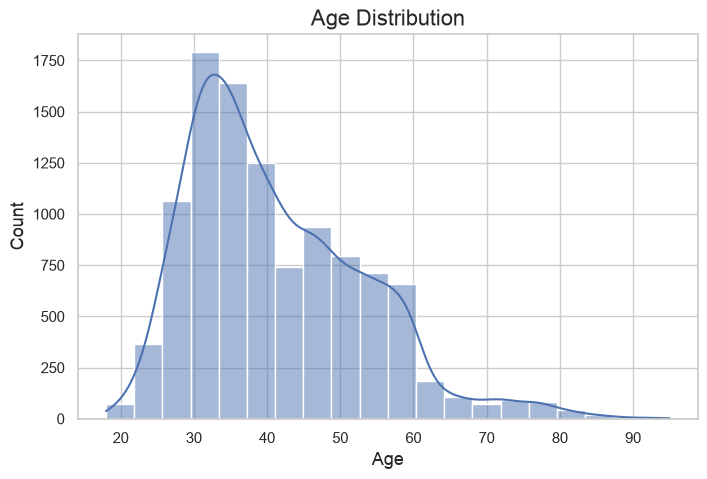

In [154]:
plt.figure(figsize=(8,5))
sns.histplot(DC_df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## 3.3 Data types and categories
Ensure numeric columns are correctly typed: age, balance, day, duration, campaign, pdays, previous should all be numeric (int/float) and not strings.
Standardize categorical values where there are only a few discrete options (marital, education, job, default, housing, loan, contact, month, poutcome, deposit) and check that there are no accidental extra categories like misspellings or inconsistent capitalization.

In [155]:
#  numeric columns
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

#  categorical columns
categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'poutcome', 'deposit']

# Asignar tipos
DC_df[numeric_cols] = DC_df[numeric_cols].apply(pd.to_numeric)
DC_df[categorical_cols] = DC_df[categorical_cols].astype(str)

# Comprobar los tipos
print(DC_df.dtypes)

id             int64
age          float64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day            int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
deposit          str
dtype: object


## 3.4 Duplicate
No duplicate rows or duplicate IDs were found (df.duplicated().sum() = 0 and df['id'].duplicated().sum() = 0). Consequently, no duplicate removal was necessary.

# 3.5 Outliers and extrem values
A comprehensive review of the dataset identified several extreme values across key numerical variables:
Balance: Values range from −6,847 to 81,204.
Duration: Highly elevated values were detected, reaching up to 3,881 seconds.
Campaign: Contact frequency showed extreme spikes, with a maximum of 63 contacts.
Data Preprocessing StrategyTo address these anomalies and ensure model robustness, the team will evaluate the potential application of Winsorization during the data preprocessing phase. Any data points definitively identified as data-entry errors will be systematically removed from the final dataset.
Current Treatment 
ActionBalance: The team decided to retain these outliers, as they represent valid, real-world customer financial data.
Duration and Campaign: Outliers in these variables were removed to minimize the disproportionate impact of extreme values on subsequent analyses.


In [156]:
# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_filtered = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

    return df_filtered

In [157]:
# Remove outliers from duration and campaign
# Create a copy of the original dataset
DC_df_original = DC_df.copy()

# Remove outliers from the selected columns
DC_df_no_outliers = remove_outliers_iqr(DC_df_original, 'duration')
DC_df_no_outliers = remove_outliers_iqr(DC_df_no_outliers, 'campaign')

print(f"Original number of rows: {len(DC_df_original)}")
print(f"Final number of rows: {len(DC_df_no_outliers)}")
print(f"Number of rows removed: {len(DC_df_original) - len(DC_df_no_outliers)}")

Original number of rows: 10630
Final number of rows: 9519
Number of rows removed: 1111


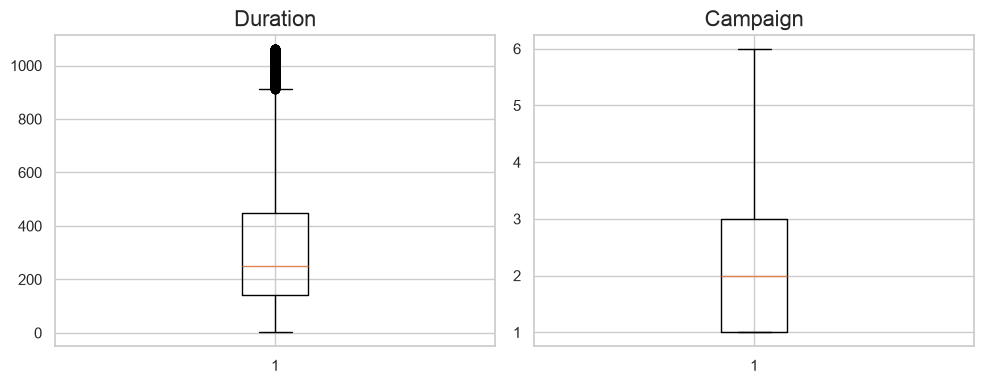

In [158]:
#Verify the result with boxplots
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].boxplot(DC_df_no_outliers['duration'])
ax[0].set_title('Duration')

ax[1].boxplot(DC_df_no_outliers['campaign'])
ax[1].set_title('Campaign')

plt.tight_layout()
plt.show()

## 3.6 Target Variable Validation and Encoding
The target variable deposit was verified to contain two categories, no (5,353 observations) and yes (5,289 observations), indicating an almost balanced class distribution. For classification modeling, the variable was encoded as a binary target, with no = 0 and yes = 1.

In [159]:
# Display the frequency of each class
print(DC_df_no_outliers['deposit'].value_counts())

# Display the class proportions
print(DC_df_no_outliers['deposit'].value_counts(normalize=True))

# Convert the target variable to binary
DC_df_no_outliers['deposit'] = DC_df_no_outliers['deposit'].map({'no': 0, 'yes': 1})

# Verify the conversion
print(DC_df_no_outliers['deposit'].value_counts())
print(DC_df_no_outliers['deposit'].dtype)

deposit
no     4886
yes    4633
Name: count, dtype: int64
deposit
no     0.513289
yes    0.486711
Name: proportion, dtype: float64
deposit
0    4886
1    4633
Name: count, dtype: int64
int64


## 3.7 Handle Special Numeric Codes
Some numeric values in the dataset represent specific categories rather than true numerical measurements. To improve model interpretability, additional binary indicator variables were created to identify customers with no previous contact (pdays = -1) and customers who had at least one previous contact (previous > 0). The original variables were retained to preserve all available information for modeling.

In [160]:
# Create an indicator for customers with no previous contact
DC_df_no_outliers['no_previous_contact'] = (DC_df_no_outliers['pdays'] == -1).astype(int)

# Verify the new variable
print(DC_df_no_outliers[['pdays', 'no_previous_contact']].head())

# Create an indicator for customers with previous contacts
DC_df_no_outliers['had_previous_contact'] = (DC_df_no_outliers['previous'] > 0).astype(int)

# Verify the new variable
print(DC_df_no_outliers[['previous', 'had_previous_contact']].head())

   pdays  no_previous_contact
0     -1                    1
3     -1                    1
4     -1                    1
5     -1                    1
7     -1                    1
   previous  had_previous_contact
0         0                     0
3         0                     0
4         0                     0
5         0                     0
7         0                     0


In [161]:
DC_df_no_outliers

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,no_previous_contact,had_previous_contact
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1,1,0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1,1,0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1,1,0
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,1,1,0
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10637,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,2,mar,169,4,-1,0,unknown,0,1,0
10638,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,15,may,98,2,-1,0,unknown,0,1,0
10639,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,20,nov,316,1,-1,0,unknown,0,1,0
10640,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,19,nov,426,2,189,6,failure,0,0,1


In [162]:
#  Export dataset to csv after cleaning process

# Create output directory if it doesn't exist
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

# Export dataframe
output_file = output_dir / "bank_dataset_cleaned_2026-07-01.csv"
DC_df_no_outliers.to_csv(output_file, index=False, encoding="utf-8")

print(f"CSV saved to: {output_file.resolve()}")

CSV saved to: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data/bank_dataset_cleaned_2026-07-01.csv
